<a href="https://colab.research.google.com/github/Fauzi455/PCVK26_12_M-Fauzi-R/blob/main/PCVK_W3_244107020067_FAUZI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sel Identitas

In [4]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Mohamat Fauzi Rohman'
NIM = '244107020067' #ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
'b' : (N % 61) + 20,
'a' : round(1.0 + (N % 9) / 10, 1),
'c' : (N % 20) + 30,
'gamma': round(0.4 + (N % 6) * 0.25, 2),
'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Mohamat Fauzi Rohman
NIM : 244107020067 | N = 67
b      : 26
a      : 1.4
c      : 37
gamma  : 0.65
bit    : 3
WAKTU : 2026-09-18 18:25:11 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 80be738652a6ade1


In [59]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Transformasi Linier Brightness

 Mengubah tingkat kecerahan citra 
------------------------------------
Masukkan nilai kecerahan: 26


/tmp/ipykernel_3084/396390312.py:21: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


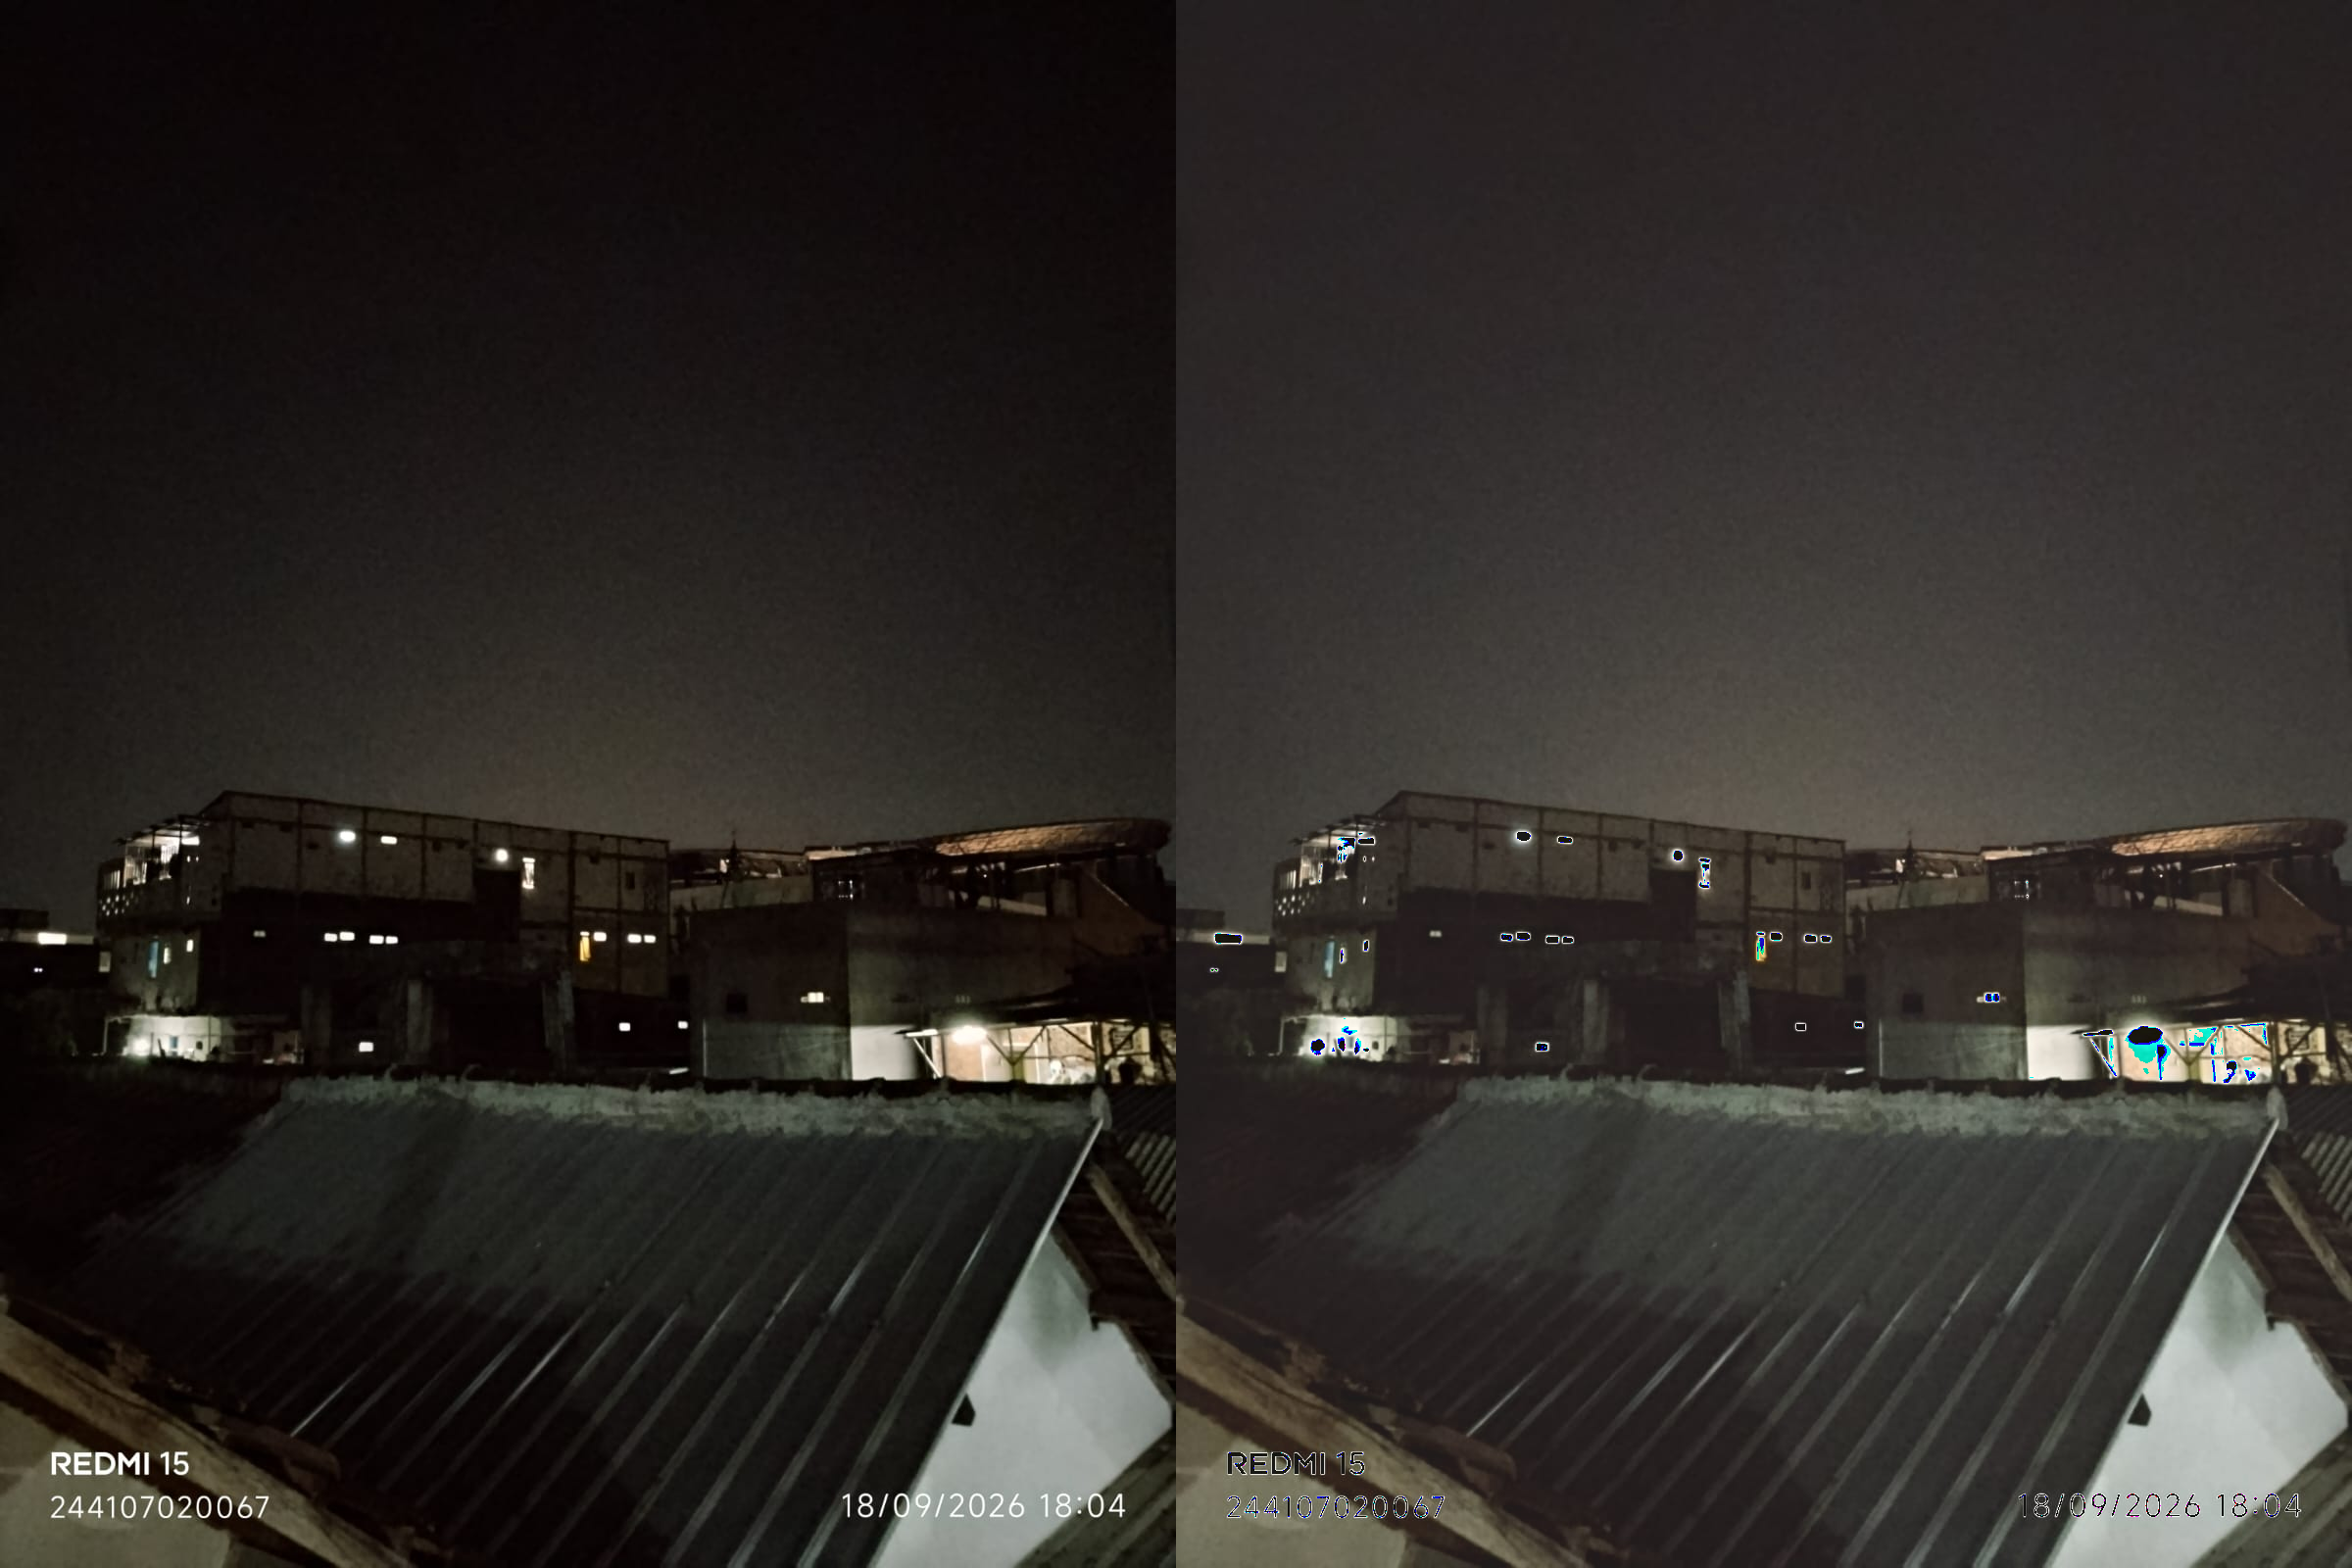

In [20]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('------------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020067/NIGHT1.jpeg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

#Tugas Praktikum

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula pada
bagian Ulasan Teori. Terapkan pada KTM1b.jpg dan KTM1a.jpg, tampilkan
berdampingan dengan citra aslinya. Jelaskan mengapa citra negatif dari KTM1a
(ruangan gelap) tampak pucat dan berkabut, sedangkan negatif dari KTM1b tetap
kontras.

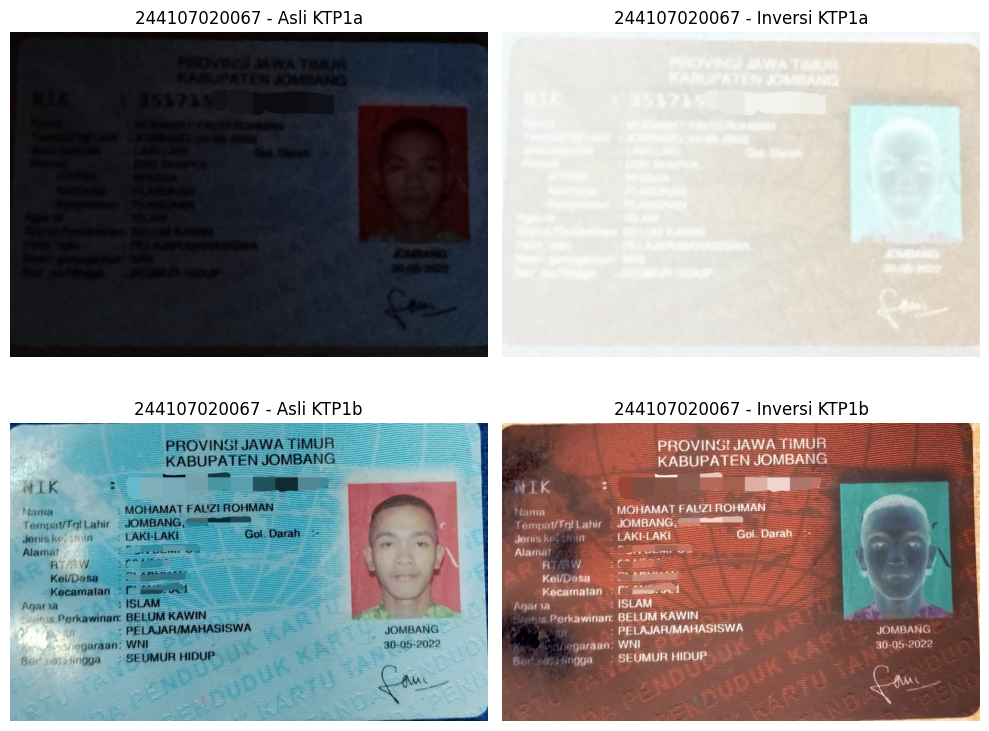

In [27]:
img_1a = cv.imread(BASE_PATH + 'KTP1a.jpeg')
img_1b = cv.imread(BASE_PATH + 'KTP1b.jpeg')

#operasi inverse
inv_1a = 255 - img_1a
inv_1b = 255 - img_1b

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(cv.cvtColor(img_1a, cv.COLOR_BGR2RGB))
axes[0, 0].set_title(f'{NIM} - Asli KTP1a')
axes[0, 1].imshow(cv.cvtColor(inv_1a, cv.COLOR_BGR2RGB))
axes[0, 1].set_title(f'{NIM} - Inversi KTP1a')

axes[1, 0].imshow(cv.cvtColor(img_1b, cv.COLOR_BGR2RGB))
axes[1, 0].set_title(f'{NIM} - Asli KTP1b')
axes[1, 1].imshow(cv.cvtColor(inv_1b, cv.COLOR_BGR2RGB))
axes[1, 1].set_title(f'{NIM} - Inversi KTP1b')

for ax in axes.ravel(): ax.axis('off')
plt.tight_layout()
plt.show()

Foto KTP1a diambil di ruangan yang gelap, sehingga warnanya dominan warna hitam. Begitu warnanya dibalik (efek negatif), warna hitam yang tadinya dominan langsung berubah menjadi putih/berkabut putih

Sedangkan KTP1b, pencahayaannya sudah pas dari awal. Sehingga ketika warnanya dibalik, hasilnya tetap kelihatan jelas dan kontrasnya tetap seimbang

2. Implementasikan transformasi kontras dengan nilai a yang dihitung dari NIM Anda
(PARAM['a']) pada KTM1a.jpg.

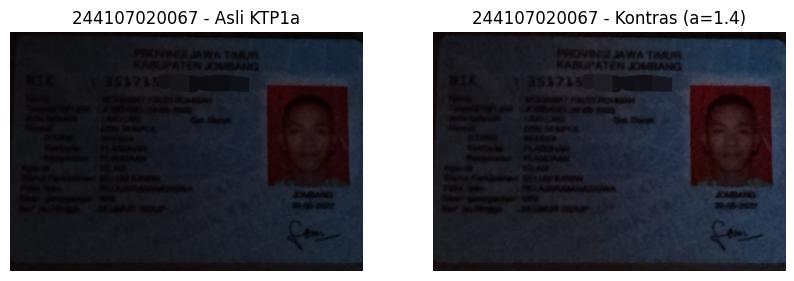

In [23]:
a = PARAM['a']
b = 0

contrast_img = np.clip(a * img_1a.astype(np.float32) + b, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_1a, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Asli KTP1a')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(contrast_img, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Kontras (a={a})')
plt.axis('off')
plt.show()

3. Implementasikan transformasi logarithmic brightness dengan konstanta c hasil hitung
dari NIM (PARAM['c']) pada KTM1a.jpg. Bandingkan hasilnya dengan linier brightness
memakai nilai b hasil hitung dari NIM (PARAM['b']) pada citra yang sama. Tentukan
metode mana yang membuat NIM pada kartu Anda lebih terbaca, dan tunjukkan
bagian mana yang menjadi putih penuh (clipping) pada masing-masing metode.

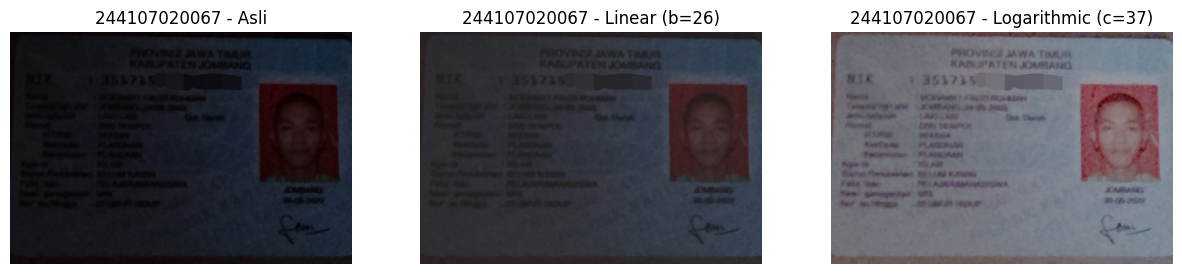

In [28]:
b_val = PARAM['b']
c_val = PARAM['c']

#linear brightness
linear_img = np.clip(img_1a.astype(np.int16) + b_val, 0, 255).astype(np.uint8)

#logarithmic brightness
img_float = img_1a.astype(np.float32)
log_img = c_val * np.log1p(img_float)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(img_1a, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(linear_img, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Linear (b={b_val})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(log_img, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Logarithmic (c={c_val})')
plt.axis('off')
plt.show()

4. Implementasikan transformasi grayscale metode averaging, lightness, dan luminance
pada KTM1c.jpg, yaitu citra yang diambil dengan flash. Hitung rata-rata dan
simpangan baku intensitas hasil ketiga metode, sajikan dalam satu tabel, lalu tentukan
metode mana yang memberi pemisahan paling jelas antara teks dan latar kartu.

Metode: Averaging            | Mean: 154.68 | Std Dev:  37.16
Metode: Lightness            | Mean: 151.45 | Std Dev:  36.84
Metode: Luminance (Rec. 601) | Mean: 150.65 | Std Dev:  37.54


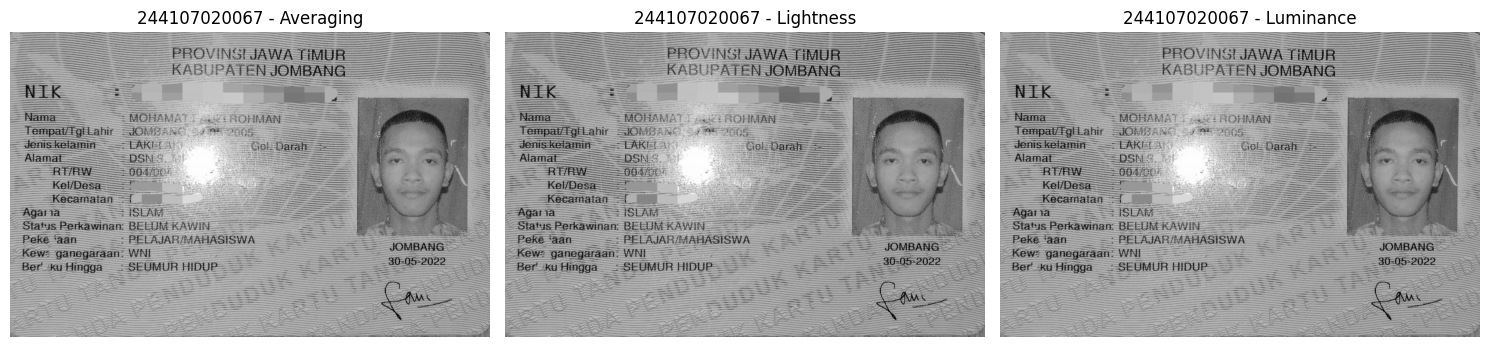

In [29]:
img_1c = cv.imread(BASE_PATH + 'KTP1c.jpeg')
B, G, R = cv.split(img_1c.astype(np.float32))

#tiga metode grayscale
gray_avg = ((R + G + B) / 3.0).astype(np.uint8)
gray_light = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2.0).astype(np.uint8)
gray_lum = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

stats = {
    'Metode': ['Averaging', 'Lightness', 'Luminance (Rec. 601)'],
    'Mean': [np.mean(gray_avg), np.mean(gray_light), np.mean(gray_lum)],
    'Std Dev': [np.std(gray_avg), np.std(gray_light), np.std(gray_lum)]
}

for m, mu, std in zip(stats['Metode'], stats['Mean'], stats['Std Dev']):
    print(f"Metode: {m:<20} | Mean: {mu:6.2f} | Std Dev: {std:6.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray_avg, cmap='gray'); axes[0].set_title(f'{NIM} - Averaging')
axes[1].imshow(gray_light, cmap='gray'); axes[1].set_title(f'{NIM} - Lightness')
axes[2].imshow(gray_lum, cmap='gray'); axes[2].set_title(f'{NIM} - Luminance')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

5. Tampilkan satu warna tertentu pada citra dan ubah bagian lainnya menjadi grayscale.
Gunakan OBJ1.jpg, yaitu foto benda milik Anda sendiri dengan satu warna dominan.
Sebutkan rentang nilai HSV yang Anda pakai sebagai batas warna, lalu tunjukkan
pengaruhnya apabila rentang tersebut diperlebar dan dipersempit.

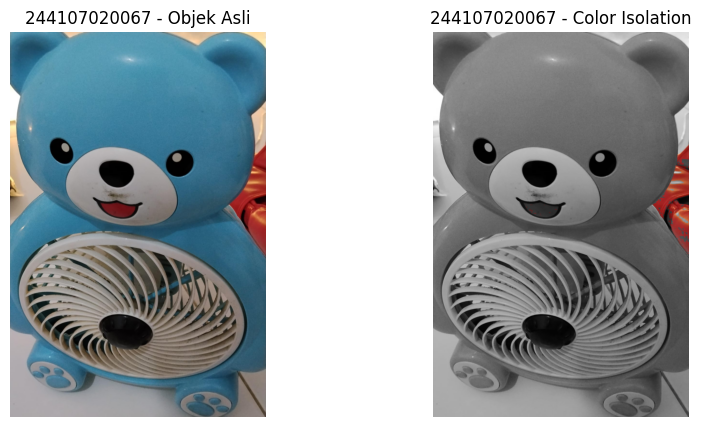

In [37]:
img_obj = cv.imread(BASE_PATH + 'OBJ1.jpeg')
hsv_obj = cv.cvtColor(img_obj, cv.COLOR_BGR2HSV)

#deteksi objek warna merah
lower_bound = np.array([0, 100, 100])
upper_bound = np.array([10, 255, 255])
mask = cv.inRange(hsv_obj, lower_bound, upper_bound)

#mengubah background menjadi grayscale
gray_background = cv.cvtColor(cv.cvtColor(img_obj, cv.COLOR_BGR2GRAY), cv.COLOR_GRAY2BGR)

result_isolation = np.where(mask[:, :, None] == 255, img_obj, gray_background)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_obj, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Objek Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result_isolation, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Color Isolation')
plt.axis('off')
plt.show()

6. Gamma Correction pada Citra Pribadi

Nilai gamma diminta dari pengguna melalui kode di bawah ini. Lanjutkan kode tersebut
sesuai rumus pada Ulasan Teori, kemudian terapkan pada KTM1a.jpg. Mulailah dari nilai
gamma hasil hitung dari NIM Anda, lalu cari secara bertahap nilai gamma yang membuat
NIM dan nama pada kartu paling terbaca. Tampilkan minimal lima nilai gamma yang

dicoba beserta hasilnya, sebutkan nilai gamma terbaik pilihan Anda, dan jelaskan
mengapa nilai terbaik setiap mahasiswa berbeda meskipun jenis objeknya sama.

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.65
Error, not a number


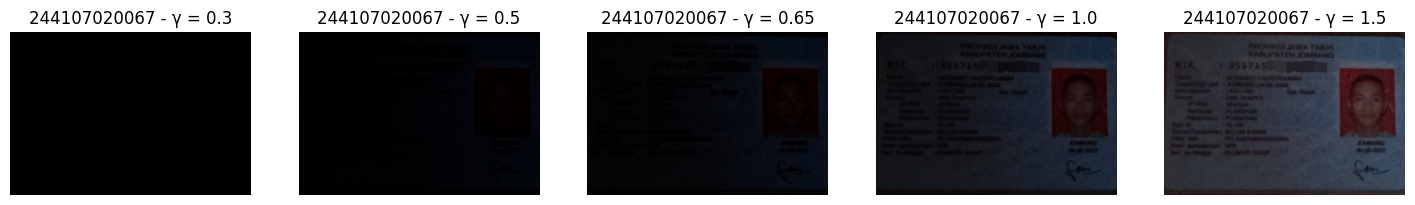

In [43]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
  gamma = int(input('Masukkan nilai Gamma: '))
except ValueError:
  print('Error, not a number')

gamma_base = PARAM['gamma']
gammas = [0.3, 0.5, gamma_base, 1.0, 1.5]

plt.figure(figsize=(18, 4))
for i, g in enumerate(gammas):
    inv_g = 1.0 / g
    table = np.array([((i / 255.0) ** inv_g) * 255 for i in np.arange(0, 256)]).astype(np.uint8)
    corrected = cv.LUT(img_1a, table)

    plt.subplot(1, 5, i+1)
    plt.imshow(cv.cvtColor(corrected, cv.COLOR_BGR2RGB))
    plt.title(f'{NIM} - γ = {g}')
    plt.axis('off')
plt.show()

7. Buat Simulasi Image Depth pada Citra Pribadi

Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit).
Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga
255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0
(000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit.
Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst.
Kuantisasi KTM1b.jpg pada kedalaman 1 sampai 7 bit dan tampilkan seluruh hasilnya.
Tentukan pada kedalaman berapa nama dan NIM pada kartu Anda masih terbaca,

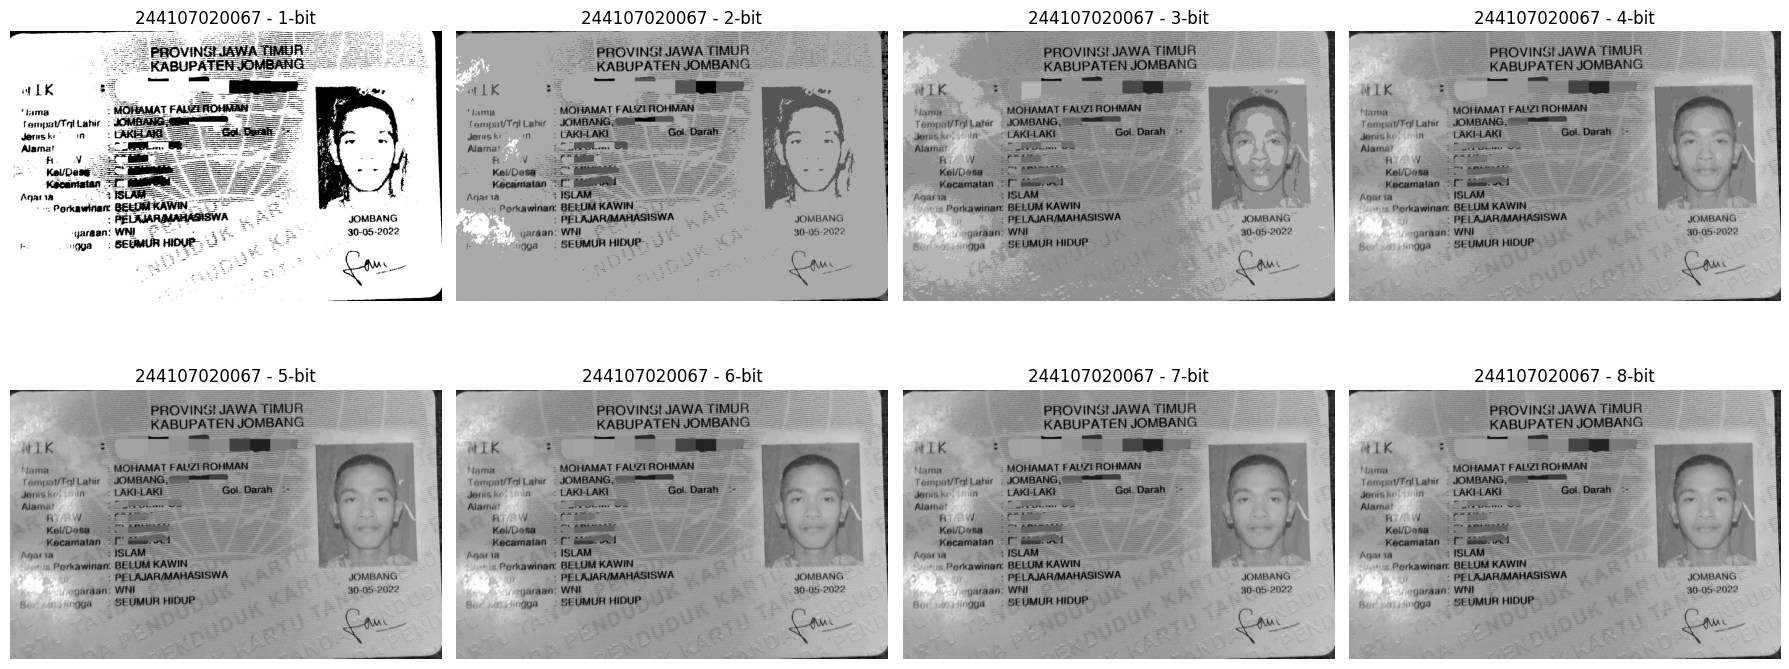

In [48]:
gray_1b = cv.imread(BASE_PATH + 'KTP1b.jpeg', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(18, 8))
for bit in range(1, 8):
    level = 255.0 / (pow(2, bit) - 1)
    quantized = (np.round(gray_1b / level) * level).astype(np.uint8)

    plt.subplot(2, 4, bit)
    plt.imshow(quantized, cmap='gray')
    plt.title(f'{NIM} - {bit}-bit')
    plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(gray_1b, cmap='gray')
plt.title(f'{NIM} - 8-bit')
plt.axis('off')
plt.tight_layout()
plt.show()

8. Average Denoising

Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.
Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg
Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,
gunakan modul glob (import glob).
cv_img = []
for img in glob.glob('/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/noises/*.jpg'):
n= cv.imread(img)
cv_img.append(n)
Dengan menggunakan code diatas, anda tinggal memanggil image difolder tersebut
menggunakan cv_img[0], cv_img[1], dst.
Catat hasil PSNR pada tabel berikut. Dari hasil yang sudah anda catat, tuliskan
kesimpulan anda:

Ditemukan 100 file noise: ['/content/drive/MyDrive/PCVK/Images/244107020067/noises/1.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/10.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/100.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/11.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/12.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/13.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/14.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/15.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/16.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/17.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/18.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/19.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/2.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/20.jpg', '/content/drive/MyDrive/PCVK/Images/244107020067/noises/21.jpg',

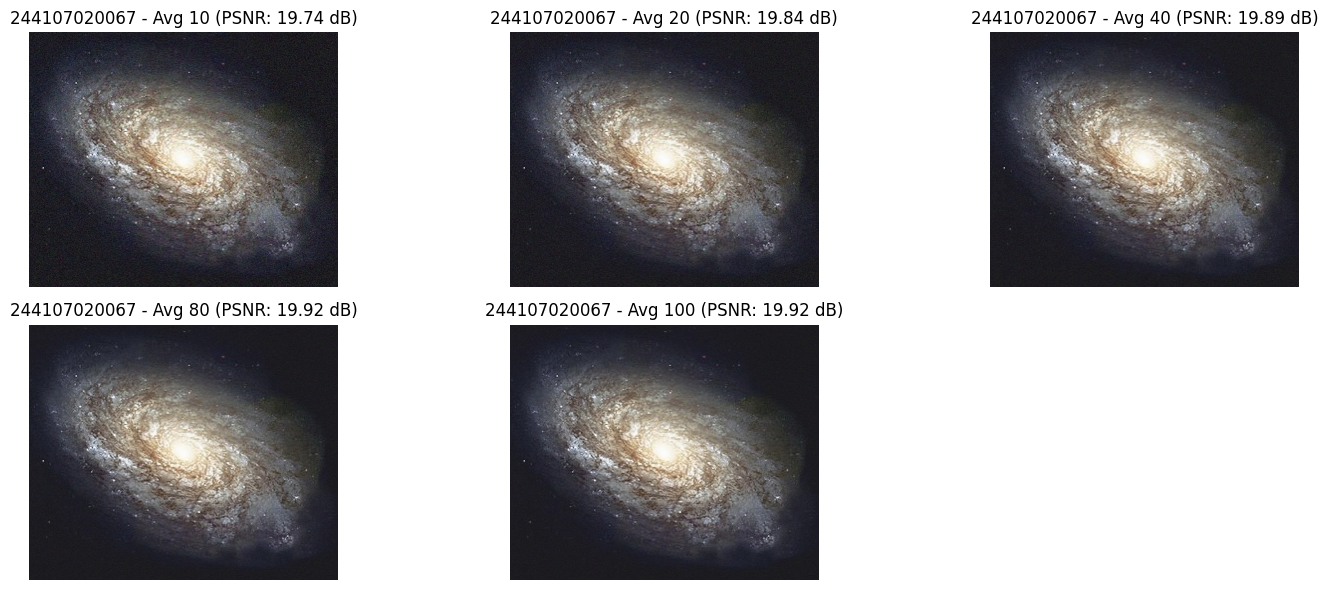

In [67]:
from math import log10, sqrt

def calc_PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

#baca citra dari noises
orig_galaxy = cv.imread('/content/drive/MyDrive/PCVK/Images/244107020067/galaxy.jpg')
noise_files = sorted(glob.glob('/content/drive/MyDrive/PCVK/Images/244107020067/noises/*.jpg'))
noisy_imgs = [cv.imread(f) for f in noise_files]

print(f"Ditemukan {len(noise_files)} file noise: {noise_files}")

test_counts = [10, 20, 40, 80, 100]
results_psnr = []

plt.figure(figsize=(15, 6))
for idx, count in enumerate(test_counts):
    #rata-rata jumlah n citra
    subset = np.array(noisy_imgs[:count], dtype=np.float32)
    avg_img = np.mean(subset, axis=0).astype(np.uint8)

    val_psnr = calc_PSNR(orig_galaxy, avg_img)
    results_psnr.append(val_psnr)

    plt.subplot(2, 3, idx + 1)
    plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
    plt.title(f'{NIM} - Avg {count} (PSNR: {val_psnr:.2f} dB)')
    plt.axis('off')

plt.tight_layout()
plt.show()

9. Buat Image Masking untuk Penyamaran Data Pribadi

Buat mask biner Anda sendiri yang menutup area foto wajah dan area NIM pada
KTM1d.jpg, lalu gabungkan dengan citra menggunakan operator AND sehingga kedua
area tersebut tersamarkan. Tuliskan koordinat kotak mask yang Anda pakai.

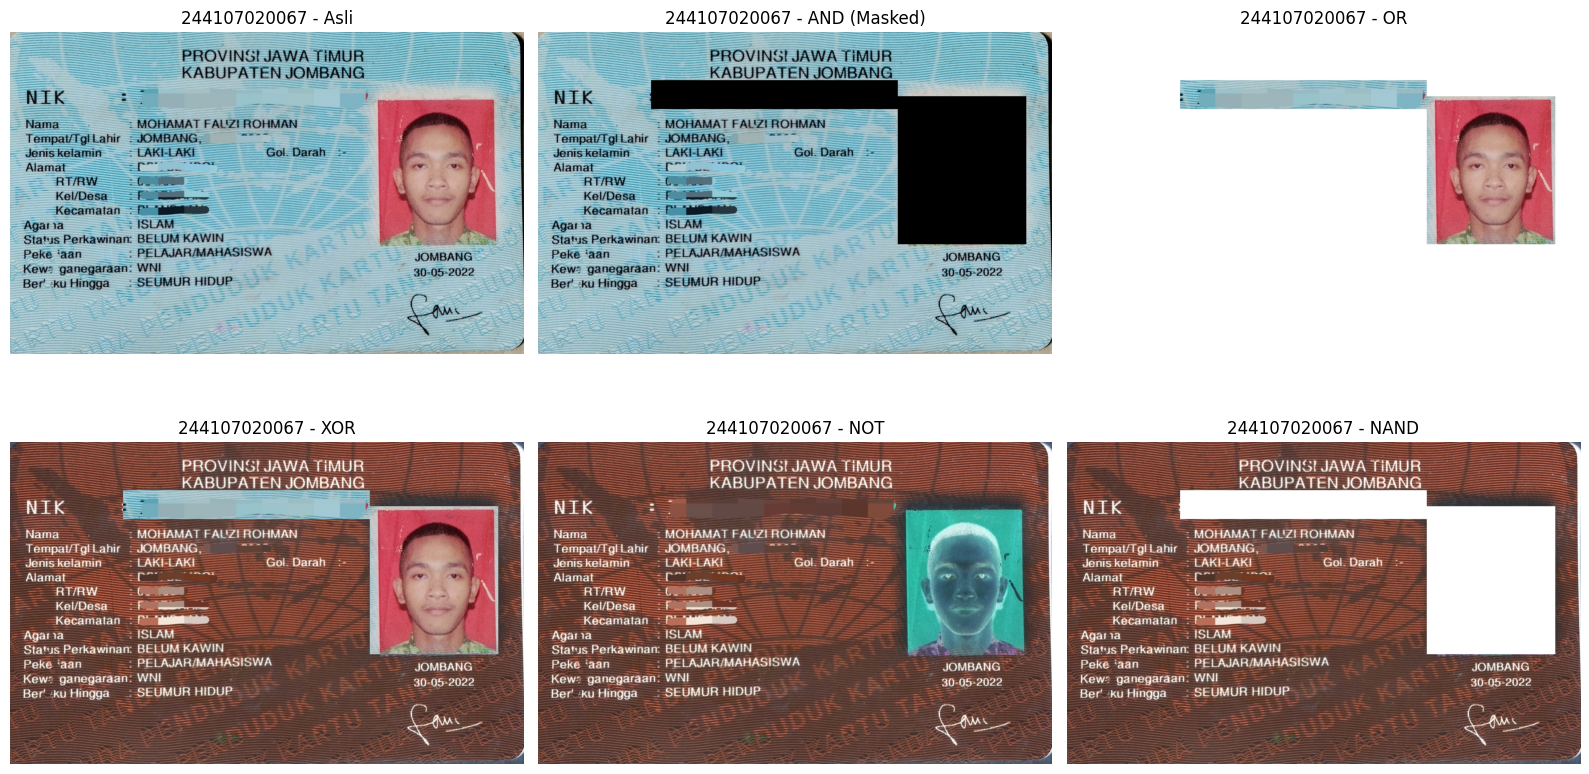

In [69]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = "244107020067"

# Baca citra KTP
img_ktp = cv.imread(BASE_PATH + 'KTP1d.jpeg')  # Sesuaikan nama file citra KTP Anda

# Dapatkan dimensi gambar (tinggi dan lebar)
h, w = img_ktp.shape[:2]

# Inisialisasi mask putih (255) satu channel
mask_card = np.ones((h, w), dtype=np.uint8) * 255

# 1. Area Pasfoto (Kanan): Tinggi ~20% s.d. 66%, Lebar ~70% s.d. 95%
mask_card[int(h * 0.20):int(h * 0.66), int(w * 0.70):int(w * 0.95)] = 0

# 2. Area NIK (Kiri Atas): Tinggi ~15% s.d. 24%, Lebar ~22% s.d. 70%
mask_card[int(h * 0.15):int(h * 0.24), int(w * 0.22):int(w * 0.70)] = 0

# Duplikasi mask ke 3 channel (BGR)
mask_3ch = cv.merge([mask_card, mask_card, mask_card])

# Operasi Logika Bitwise
masked_and  = cv.bitwise_and(img_ktp, mask_3ch)
masked_or   = cv.bitwise_or(img_ktp, mask_3ch)
masked_xor  = cv.bitwise_xor(img_ktp, mask_3ch)
masked_not  = cv.bitwise_not(img_ktp)
masked_nand = cv.bitwise_not(masked_and)

# Visualisasi
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes[0, 0].imshow(cv.cvtColor(img_ktp, cv.COLOR_BGR2RGB));     axes[0, 0].set_title(f'{NIM} - Asli')
axes[0, 1].imshow(cv.cvtColor(masked_and, cv.COLOR_BGR2RGB)); axes[0, 1].set_title(f'{NIM} - AND (Masked)')
axes[0, 2].imshow(cv.cvtColor(masked_or, cv.COLOR_BGR2RGB));  axes[0, 2].set_title(f'{NIM} - OR')
axes[1, 0].imshow(cv.cvtColor(masked_xor, cv.COLOR_BGR2RGB)); axes[1, 0].set_title(f'{NIM} - XOR')
axes[1, 1].imshow(cv.cvtColor(masked_not, cv.COLOR_BGR2RGB)); axes[1, 1].set_title(f'{NIM} - NOT')
axes[1, 2].imshow(cv.cvtColor(masked_nand, cv.COLOR_BGR2RGB));axes[1, 2].set_title(f'{NIM} - NAND')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

- Operasi AND: Yaitu menyensor data pribadi area wajah dan NIK langsung berubah menjadi hitam, sedangkan bagian KTP yang lain warnanya tetap normal seperti aslinya.   
- Operasi OR: Kebalikan dari AND yang dimana bagian luar KTP dibuat jadi putih semua, sementara bagian wajah dan NIK tetap kelihatan normal
- Operasi XOR: Bagian wajah dan NIK warnanya tetap asli, sedangkan sisanya berubah menjadi efek negatif
- Operasi NOT: Efek negatif total pada KTP yang membuat warnanya seperti foto rontgen   
- Operasi NAND: Kebalikan dari efek AND yang dimana kotak sensor yang semula warnanya hitam sekarang berubah jadi putih

10. Foto Malam Hari

Carilah foto malam hari yang gelap. Namun, beberapa bagian gambar memiliki detail yang
sebenarnya cukup baik. Pilih salah satu metode berikut dan implementasikan pada foto
tersebut (Linear Brightness, Contrast, Logarithmic Brightness, Gamma Correction). Sebutkan
alasan dan resiko metode yang Anda gunakan.

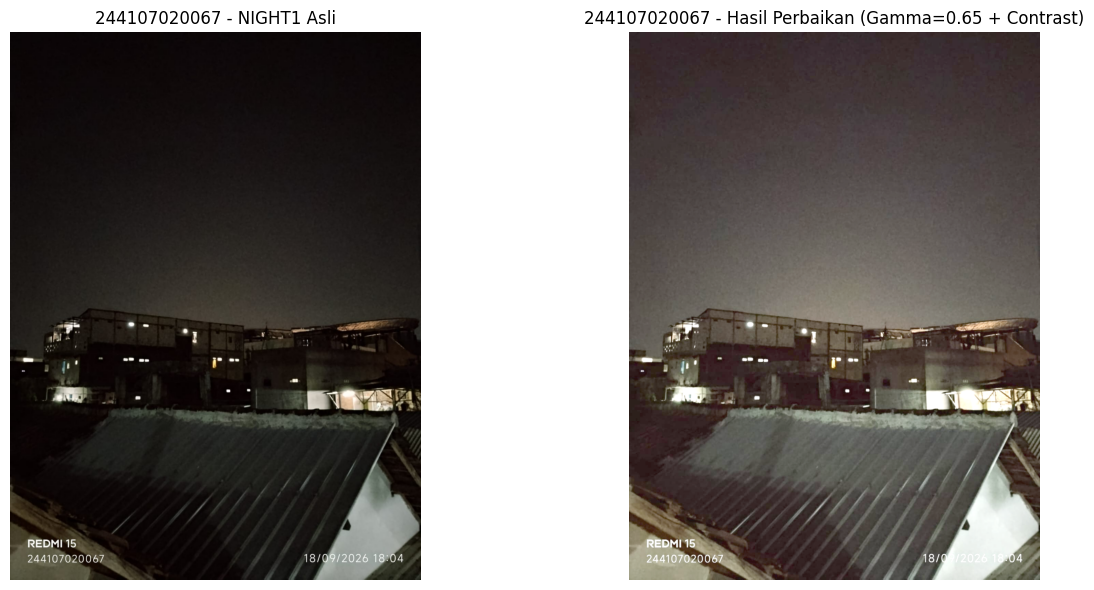

In [75]:
night_img = cv.imread(BASE_PATH + 'NIGHT1.jpeg')
gamma_val = 0.65
table = np.array([((i / 255.0) ** gamma_val) * 255 for i in np.arange(0, 256)]).astype(np.uint8)
brightened = cv.LUT(night_img, table)


plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(night_img, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - NIGHT1 Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Hasil Perbaikan (Gamma={gamma_val} + Contrast)')
plt.axis('off')

plt.tight_layout()
plt.show()

- Metode yang dipilih : Menggunakan metode Gamma Correction
- Alasan pemilihan : Karena Gamma berfokus untuk mengangkat bagian yang gelap saja sehingga objeknya lebih terlihat, yang dimana tanpa membuat bagian yang sudah terang jadi makin terang/silau
- Menentukan parameter terbaik : Nilai patokan gamma normal adalah 1.0 dan untuk menerangkan foto gelap nilainya harus di bawah 1.0. Saya memilih nilai 0.65 karena sesuai dengan Gamma saya hasil perhitungan diatas